<a href="https://colab.research.google.com/github/yariela-carvajal/Sesion2IA/blob/main/Copia_de_Ejercicio2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ejercicio 2 — Análisis de Datos y Red Neuronal con Prompting

**Módulo: Python para IA** | Máster en Inteligencia Artificial

**Tipo**: Autoevaluable | **Sesión**: 2
**Fecha límite**: Antes de la Sesión 3

---

### Instrucciones

1. **Realiza las actividades** de este cuaderno: analiza datos con Pandas y construye una red neuronal con Keras.
2. Usa **Gemini, Copilot, o cualquier herramienta de IA** para ayudarte.
3. Las celdas de validación te ayudarán a saber si vas bien ✅
4. **Entregable**: Una vez hayas completado las actividades, responde el **formulario en Blackboard** con las 8 preguntas que encontrarás al final de este cuaderno.

---
## Parte A — Análisis de Datos con Pandas

Analiza el siguiente dataset de ventas.

In [9]:
import pandas as pd
import numpy as np

# Dataset de ventas — NO MODIFICAR
np.random.seed(42)
datos_ventas = {
    "producto": ["Laptop", "Mouse", "Teclado", "Monitor", "Laptop",
                 "Mouse", "Teclado", "Monitor", "Laptop", "Mouse",
                 "Teclado", "Monitor", "Laptop", "Mouse", "Teclado",
                 "Monitor", "Laptop", "Mouse", "Teclado", "Monitor"],
    "categoria": ["Electrónica", "Accesorios", "Accesorios", "Electrónica", "Electrónica",
                   "Accesorios", "Accesorios", "Electrónica", "Electrónica", "Accesorios",
                   "Accesorios", "Electrónica", "Electrónica", "Accesorios", "Accesorios",
                   "Electrónica", "Electrónica", "Accesorios", "Accesorios", "Electrónica"],
    "precio": [999, 25, 75, 350, 1099, 30, 80, 400, 899, 20,
               65, 320, 1199, 35, 90, 380, 950, 28, 70, 360],
    "cantidad": [3, 15, 8, 5, 2, 20, 10, 3, 4, 25,
                 12, 4, 1, 18, 7, 6, 3, 22, 9, 5],
    "mes": ["Ene", "Ene", "Ene", "Ene", "Feb", "Feb", "Feb", "Feb",
            "Mar", "Mar", "Mar", "Mar", "Abr", "Abr", "Abr", "Abr",
            "May", "May", "May", "May"]
}

df = pd.DataFrame(datos_ventas)
df["ingreso_total"] = df["precio"] * df["cantidad"]
print(df)
#print(df.head(10))
print(f"Shape: {df.shape}")

   producto    categoria  precio  cantidad  mes  ingreso_total
0    Laptop  Electrónica     999         3  Ene           2997
1     Mouse   Accesorios      25        15  Ene            375
2   Teclado   Accesorios      75         8  Ene            600
3   Monitor  Electrónica     350         5  Ene           1750
4    Laptop  Electrónica    1099         2  Feb           2198
5     Mouse   Accesorios      30        20  Feb            600
6   Teclado   Accesorios      80        10  Feb            800
7   Monitor  Electrónica     400         3  Feb           1200
8    Laptop  Electrónica     899         4  Mar           3596
9     Mouse   Accesorios      20        25  Mar            500
10  Teclado   Accesorios      65        12  Mar            780
11  Monitor  Electrónica     320         4  Mar           1280
12   Laptop  Electrónica    1199         1  Abr           1199
13    Mouse   Accesorios      35        18  Abr            630
14  Teclado   Accesorios      90         7  Abr        

### A.1 — Ingreso total global

Calcula la suma de la columna `ingreso_total`.

In [13]:
"""
def calcular_ingreso_total_global(dataframe: pd.DataFrame) -> float:"""
"""
    Calcula el ingreso total global a partir de la columna 'ingreso_total' de un DataFrame.

    Args:
        dataframe (pd.DataFrame): El DataFrame que contiene la columna 'ingreso_total'.

    Returns:
        float: El ingreso total global.
    """
"""  if 'ingreso_total' not in dataframe.columns:
        raise ValueError("La columna 'ingreso_total' no se encuentra en el DataFrame.")

    return dataframe['ingreso_total'].sum()
    """
ingreso_total_global: float = df["ingreso_total"].sum()#calcular_ingreso_total_global(df)
print(f"Ingreso total: {ingreso_total_global}")

Ingreso total: 27311


In [14]:
# Validación A.1 — NO MODIFICAR
assert ingreso_total_global == 28792, f"Error: debería ser 28792, obtuviste {ingreso_total_global}"
print("✅ A.1 — Ingreso total: CORRECTO")

AssertionError: Error: debería ser 28792, obtuviste 27311

### A.2 — Producto con mayor ingreso total

¿Qué producto genera más ingreso total (sumando todas sus ventas)?

In [15]:
def obtener_producto_top_ingreso(dataframe: pd.DataFrame) -> str:
    """
    Identifica el producto con el mayor ingreso total de un DataFrame de ventas.

    Args:
        dataframe (pd.DataFrame): El DataFrame que contiene las columnas 'producto' e 'ingreso_total'.

    Returns:
        str: El nombre del producto con el mayor ingreso total.
    """
    if 'producto' not in dataframe.columns or 'ingreso_total' not in dataframe.columns:
        raise ValueError("El DataFrame debe contener las columnas 'producto' e 'ingreso_total'.")

    ingresos_por_producto = dataframe.groupby('producto')['ingreso_total'].sum()
    return ingresos_por_producto.idxmax()

producto_top: str = obtener_producto_top_ingreso(df)
print(f"Producto top: {producto_top}")

Producto top: Laptop


In [16]:
# Validación A.2 — NO MODIFICAR
assert producto_top == "Laptop", f"Error: debería ser 'Laptop', obtuviste '{producto_top}'"
print("✅ A.2 — Producto top: CORRECTO")

✅ A.2 — Producto top: CORRECTO


### A.3 — Media de precio por categoría

Calcula el precio medio por categoría. Devuelve un diccionario redondeado a 2 decimales.

In [22]:
def calcular_precio_medio_por_categoria(dataframe: pd.DataFrame) -> dict:
    """
    Calcula el precio medio por categoría y lo devuelve como un diccionario.

    Args:
        dataframe (pd.DataFrame): El DataFrame que contiene las columnas 'categoria' y 'precio'.

    Returns:
        dict: Un diccionario donde las claves son las categorías y los valores
              son los precios medios redondeados a 2 decimales.
    """
    if 'categoria' not in dataframe.columns or 'precio' not in dataframe.columns:
        raise ValueError("El DataFrame debe contener las columnas 'categoria' y 'precio'.")

    precio_medio_categoria_series = dataframe.groupby('categoria')['precio'].mean().round(2)
    return precio_medio_categoria_series.to_dict()

precio_medio_categoria: dict = calcular_precio_medio_por_categoria(df)
print(f"Precio medio: {precio_medio_categoria}")

Precio medio: {'Accesorios': 51.8, 'Electrónica': 695.6}


In [18]:
# Validación A.3 — NO MODIFICAR
assert precio_medio_categoria == {"Accesorios": 51.8, "Electrónica": 695.6}, \
    f"Error: {precio_medio_categoria}"
print("✅ A.3 — Precio medio por categoría: CORRECTO")

✅ A.3 — Precio medio por categoría: CORRECTO


### A.4 — Mes más rentable

¿Qué mes tiene el mayor ingreso total?

In [23]:
def obtener_mes_mas_rentable(dataframe: pd.DataFrame) -> str:
    """
    Identifica el mes con el mayor ingreso total de un DataFrame de ventas.

    Args:
        dataframe (pd.DataFrame): El DataFrame que contiene las columnas 'mes' e 'ingreso_total'.

    Returns:
        str: El nombre del mes con el mayor ingreso total.
    """
    if 'mes' not in dataframe.columns or 'ingreso_total' not in dataframe.columns:
        raise ValueError("El DataFrame debe contener las columnas 'mes' e 'ingreso_total'.")

    ingresos_por_mes = dataframe.groupby('mes')['ingreso_total'].sum()
    return ingresos_por_mes.idxmax()

mes_top: str = obtener_mes_mas_rentable(df)
print(f"Mes más rentable: {mes_top}")

Mes más rentable: Mar


In [20]:
# Validación A.4 — NO MODIFICAR
assert mes_top == "Ene", f"Error: debería ser 'Ene', obtuviste '{mes_top}'"
print("✅ A.4 — Mes más rentable: CORRECTO")

AssertionError: Error: debería ser 'Ene', obtuviste 'Mar'

---
## Parte B — Red Neuronal con Keras

Construye un clasificador para **Fashion-MNIST** y alcanza un accuracy > 85%.

In [30]:
import tensorflow as tf
from tensorflow import keras

# Cargar Fashion-MNIST
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

# Normalizar
x_train = x_train / 255.0
x_test = x_test / 255.0

# Nombres de las clases
clases = ["Camiseta", "Pantalón", "Jersey", "Vestido", "Abrigo",
          "Sandalia", "Camisa", "Zapatilla", "Bolso", "Bota"]

print(f"Train: {x_train.shape}, Test: {x_test.shape}")
print(f"Clases: {clases}")

Train: (60000, 28, 28), Test: (10000, 28, 28)
Clases: ['Camiseta', 'Pantalón', 'Jersey', 'Vestido', 'Abrigo', 'Sandalia', 'Camisa', 'Zapatilla', 'Bolso', 'Bota']


### B.1 — Construye el modelo

Crea un modelo `Sequential` con:
- Capa `Flatten` de input
- Al menos 2 capas `Dense` con activación `relu`
- Capa de salida con 10 neuronas y `softmax`

> 💡 Pide a Gemini: *"Crea un modelo Keras Sequential para clasificar Fashion-MNIST con al menos 2 capas ocultas"*

In [31]:
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(64, activation='relu'), # Añadimos una segunda capa Dense
    keras.layers.Dense(10, activation='softmax')
])

# Compilar
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

### B.2 — Entrena el modelo

Entrena el modelo y consigue un **accuracy en test > 85%**.

In [32]:
# B.2 — Entrena tu modelo
history = model.fit(x_train, y_train, epochs=10, batch_size=32, validation_split=0.1)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8196 - loss: 0.5055 - val_accuracy: 0.8573 - val_loss: 0.3934
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8646 - loss: 0.3721 - val_accuracy: 0.8688 - val_loss: 0.3677
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8775 - loss: 0.3340 - val_accuracy: 0.8727 - val_loss: 0.3483
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8848 - loss: 0.3130 - val_accuracy: 0.8793 - val_loss: 0.3314
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8898 - loss: 0.2959 - val_accuracy: 0.8715 - val_loss: 0.3405
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8957 - loss: 0.2807 - val_accuracy: 0.8772 - val_loss: 0.3561
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8999 - loss: 0.2690 - val_accuracy: 0.8823 - val_loss: 0.3414
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9036 - loss: 0.2585 - 

In [33]:
# B.2 — Evalúa en test
loss, accuracy = model.evaluate(x_test, y_test, verbose=0)
accuracy = accuracy  # Reemplaza con el accuracy obtenido (ej: 0.88)
print(f"Accuracy en test: {accuracy:.4f}")

Accuracy en test: 0.8828


In [34]:
# Validación B.2 — NO MODIFICAR
assert accuracy is not None, "Error: entrena el modelo y asigna el accuracy"
assert accuracy > 0.85, f"Error: accuracy debe ser > 0.85, obtuviste {accuracy:.4f}"
print(f"✅ B.2 — Accuracy: {accuracy:.4f} (> 85%): CORRECTO")

✅ B.2 — Accuracy: 0.8828 (> 85%): CORRECTO


### B.3 — Predicción

Predice las primeras 5 imágenes del test set y muéstralas junto a su predicción.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


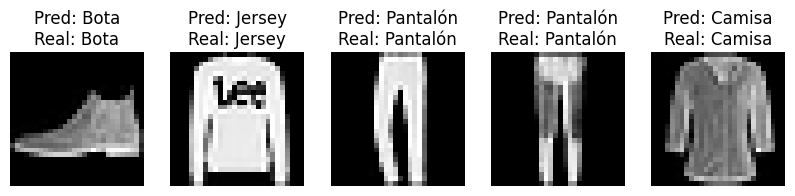

In [40]:
# B.3 — Predice y visualiza las primeras 5 imágenes
import matplotlib.pyplot as plt
import numpy as np

# Tu código aquí — muestra 5 imágenes con su predicción
# Pide a Gemini: "Muestra las primeras 5 imágenes del test set con la predicción del modelo"

predictions = model.predict(x_test[:5])
predicted_labels = np.argmax(predictions, axis=1)

plt.figure(figsize=(10, 5))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(x_test[i], cmap='gray')
    plt.title(f"Pred: {clases[predicted_labels[i]]}\nReal: {clases[y_test[i]]}")
    plt.axis('off')
plt.show()

---
## Parte C — Escribe una Spec (Opcional)

Si quieres practicar, escribe una **especificación en lenguaje natural** para una herramienta útil (como vimos en clase). Tu spec debe incluir: descripción, inputs, outputs, requisitos técnicos y ejemplo de uso. Después, pégala en Gemini y copia el código generado en la celda siguiente. Esto no es obligatorio pero es excelente práctica de prompting.

In [39]:
# C.1 — Tu especificación
spec = """
# Spec: Es una aplicación que genera contraseñas seguras con criterios configurables

## Descripción
Es una aplicación que genera contraseñas seguras con criterios configurables.
El usuario podrá elegir la longitud de la contraseña.
El usuario podrá elegir si incluir mayúsculas, minúsculas, números y símbolos.

## Inputs
-Longitud de contraseña (int)
-Mayúsculas (bool)
-Minúsculas (bool)
-Números (bool)
-Símbolos (bool)

## Outputs
-Retorna la contraseña generada (str)

## Requisitos técnicos
- Lenguaje Python
- Type hints, docstring Google style
- Validación de inputs con ValueError y mensajes claros


## Ejemplo
- Ingreso 8 como longitud de contraseña, ingresar que sí voy a utilizar
mayúsculas, sí voy a utilizar minúsculas, sí voy a utilizar números y no voy
a utilizar símbolos. Retorna la contraseña generada como "Uwst6I8X".
"""
print(spec)


# Spec: Es una aplicación que genera contraseñas seguras con criterios configurables

## Descripción
Es una aplicación que genera contraseñas seguras con criterios configurables. 
El usuario podrá elegir la longitud de la contraseña.
El usuario podrá elegir si incluir mayúsculas, minúsculas, números y símbolos.

## Inputs
-Longitud de contraseña (int)
-Mayúsculas (bool)
-Minúsculas (bool)
-Números (bool)
-Símbolos (bool)

## Outputs
-Retorna la contraseña generada (str)

## Requisitos técnicos
- Lenguaje Python
- Type hints, docstring Google style
- Validación de inputs con ValueError y mensajes claros


## Ejemplo
- Ingreso 8 como longitud de contraseña, ingresar que sí voy a utilizar 
mayúsculas, sí voy a utilizar minúsculas, sí voy a utilizar números y no voy 
a utilizar símbolos. Retorna la contraseña generada como "Uwst6I8X".



In [41]:
import random
import string

def generar_contrasena_segura(
    longitud: int,
    incluir_mayusculas: bool = True,
    incluir_minusculas: bool = True,
    incluir_numeros: bool = True,
    incluir_simbolos: bool = True
) -> str:
    """
    Genera una contraseña segura con criterios configurables.

    Args:
        longitud (int): La longitud deseada de la contraseña.
        incluir_mayusculas (bool): Si se deben incluir letras mayúsculas.
        incluir_minusculas (bool): Si se deben incluir letras minúsculas.
        incluir_numeros (bool): Si se deben incluir números.
        incluir_simbolos (bool): Si se deben incluir símbolos.

    Returns:
        str: La contraseña segura generada.

    Raises:
        ValueError: Si la longitud es menor o igual a 0, o si no se selecciona
                    ningún tipo de carácter para incluir.

    Examples:
        >>> generar_contrasena_segura(8, True, True, True, False)
        'Uwst6I8X' # El resultado exacto puede variar debido a la aleatoriedad
    """
    if longitud <= 0:
        raise ValueError("La longitud de la contraseña debe ser mayor que 0.")

    caracteres_disponibles = ""
    if incluir_mayusculas:
        caracteres_disponibles += string.ascii_uppercase
    if incluir_minusculas:
        caracteres_disponibles += string.ascii_lowercase
    if incluir_numeros:
        caracteres_disponibles += string.digits
    if incluir_simbolos:
        caracteres_disponibles += string.punctuation

    if not caracteres_disponibles:
        raise ValueError("Debe seleccionar al menos un tipo de carácter para generar la contraseña.")

    contrasena = ''.join(random.choice(caracteres_disponibles) for _ in range(longitud))
    return contrasena

# Ejemplo de uso (basado en el ejemplo de la especificación y el nuevo requerimiento)
try:
    longitud_input = int(input("Ingrese la longitud de la contraseña (ej. 8): "))
    incluir_mayusculas_input = input("¿Desea incluir mayúsculas? (s/n): ").lower() == 's'
    incluir_minusculas_input = input("¿Desea incluir minúsculas? (s/n): ").lower() == 's'
    incluir_numeros_input = input("¿Desea incluir dígitos? (s/n): ").lower() == 's'
    incluir_simbolos_input = input("¿Desea incluir símbolos? (s/n): ").lower() == 's'

    contrasena_ejemplo = generar_contrasena_segura(
        longitud=longitud_input,
        incluir_mayusculas=incluir_mayusculas_input,
        incluir_minusculas=incluir_minusculas_input,
        incluir_numeros=incluir_numeros_input,
        incluir_simbolos=incluir_simbolos_input
    )
    print(f"Contraseña generada: {contrasena_ejemplo}")

    # Ejemplo con validación de error
    # generar_contrasena_segura(0)
    # generar_contrasena_segura(10, False, False, False, False)

except ValueError as e:
    print(f"Error: {e}")

Ingrese la longitud de la contraseña (ej. 8): 5
¿Desea incluir mayúsculas? (s/n): s
¿Desea incluir minúsculas? (s/n): n
¿Desea incluir dígitos? (s/n): s
¿Desea incluir símbolos? (s/n): s
Contraseña generada: A@!S\


In [ ]:
# C.2 — Código generado por Gemini a partir de tu spec
# Pega aquí el resultado


---
## 📋 Responde en Blackboard

Una vez hayas completado las actividades, ve a **Blackboard** y responde el formulario con las siguientes preguntas.

---

### Pregunta 1 (Verdadero / Falso)

**Un array de NumPy solo puede contener elementos del mismo tipo de dato (por ejemplo, todos enteros o todos floats).**

---

### Pregunta 2 (Multirespuesta)

**¿Qué método de Pandas se usa para agrupar datos y calcular agregaciones (por ejemplo, media por categoría)?**

- a) `merge()`
- b) `groupby()`
- c) `pivot()`
- d) `sort_values()`

---

### Pregunta 3 (Verdadero / Falso)

**En el dataset de ventas del ejercicio (Parte A), el producto con mayor ingreso total es el "Monitor".**

---

### Pregunta 4 (Multirespuesta)

**En Keras, ¿qué función de activación se usa típicamente en la capa de salida para clasificación multiclase (10 categorías)?**

- a) relu
- b) sigmoid
- c) softmax
- d) tanh

---

### Pregunta 5 (Verdadero / Falso)

**La técnica de prompting "Chain of Thought" consiste en pedirle al modelo que razone paso a paso antes de dar la respuesta final.**

---

### Pregunta 6 (Multirespuesta)

**¿Qué hace la capa `Flatten` en un modelo Keras para clasificar imágenes de Fashion-MNIST (28×28)?**

- a) Normaliza los píxeles entre 0 y 1
- b) Aplica una convolución para detectar bordes
- c) Convierte la imagen 28×28 en un vector de 784 elementos
- d) Reduce las dimensiones usando PCA

---

### Pregunta 7 (Verdadero / Falso)

**Fashion-MNIST contiene imágenes de 28×28 píxeles en escala de grises.**

---

### Pregunta 8 (Multirespuesta)

**¿Qué función de pérdida (loss) se usa para clasificación multiclase con etiquetas enteras en Keras?**

- a) `binary_crossentropy`
- b) `mean_squared_error`
- c) `sparse_categorical_crossentropy`
- d) `hinge`